# Multi Layer Perceptron regression

Approximate the cosine function using a Multi Layer Perceptron.

Implement a simple MLP using the ReLU activation function.

In [ ]:
import sys
sys.path.append('..')

import numpy as np
from matplotlib import pyplot as plt
from autodiff.functions import relu
from autodiff.variable import Variable
from nn.losses import mse_loss
from nn.modules import Linear, Module
from nn.optimizers import SGD

class RegressionModel(Module):
    def __init__(self, in_features, out_features):
        self.linear1 = Linear(in_features, 10)
        self.linear2 = Linear(10, out_features)

    def forward(self, x):
        y = self.linear1.forward(x)
        y = relu(y)
        y = self.linear2.forward(y)
        return y

Create 100 samples of training data.

In [ ]:
data_x = [Variable([[x]]) for x in np.linspace(-3, 3, 100)]
data_y = [Variable(np.cos(x.value)) for x in data_x]

Create the model and optimizer.

In [ ]:
model = RegressionModel(1, 1)
optimizer = SGD(model.parameters(), lr=1e-3)
epochs = 100

Train the model using the Mean Squared Error loss.

Epoch 0: 2.932399696836794
Epoch 1: 0.491081575133516
Epoch 2: 0.49173676052427234
Epoch 3: 0.46825670288682686
Epoch 4: 0.4466660589199734
Epoch 5: 0.42834607450478157
Epoch 6: 0.41267684149257067
Epoch 7: 0.39907359729626785
Epoch 8: 0.38708797829911956
Epoch 9: 0.37638383178669477
Epoch 10: 0.3666970422201031
Epoch 11: 0.3578282862426692
Epoch 12: 0.3496259666092949
Epoch 13: 0.34196899180635865
Epoch 14: 0.3347645923049256
Epoch 15: 0.32794032964279834
Epoch 16: 0.3214393055730104
Epoch 17: 0.3152166414314365
Epoch 18: 0.3092367712982847
Epoch 19: 0.3034713754394263
Epoch 20: 0.2978744973755114
Epoch 21: 0.2924388602285211
Epoch 22: 0.28715374420818873
Epoch 23: 0.2820071028122921
Epoch 24: 0.2769890998402859
Epoch 25: 0.2720917348909213
Epoch 26: 0.2673085036713924
Epoch 27: 0.2625938584487158
Epoch 28: 0.2579553776919431
Epoch 29: 0.2534076385740969
Epoch 30: 0.24894807877570313
Epoch 31: 0.24457463066539023
Epoch 32: 0.24024478596127324
Epoch 33: 0.23594569035646817
Epoch 34: 0.

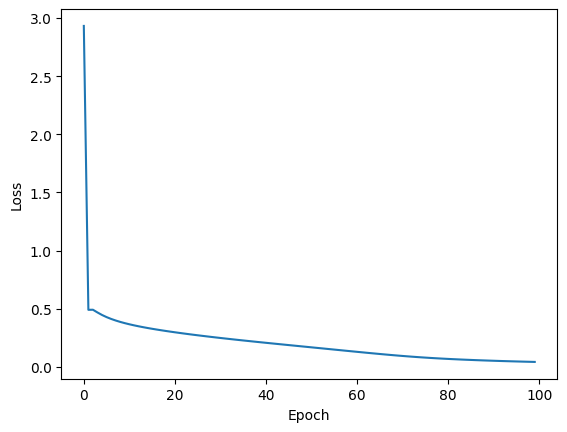

In [ ]:
losses = []
for e in range(epochs):
    epoch_losses = []
    for d, t in zip(data_x, data_y):
        pred = model.forward(d)

        loss = mse_loss(pred, t)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        epoch_losses.append(loss.value.squeeze())

    epoch_loss = sum(epoch_losses) / len(data_x)
    print(f'Epoch {e}: {epoch_loss}')
    losses.append(epoch_loss)

plt.plot(np.arange(len(losses)), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Predict some test samples. The ReLU function is not a good approximation of the cosine.

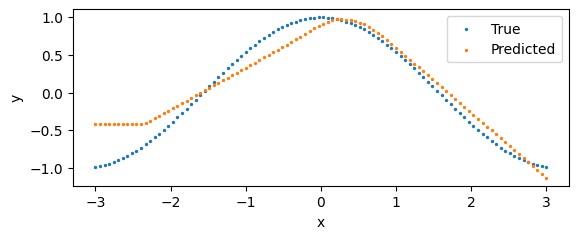

In [ ]:
pred = [model.forward(x).value for x in data_x]

plt.xlabel("x")
plt.ylabel("y")
plt.scatter(data_x, [y.value for y in data_y], label="True", s=2)
plt.scatter(data_x, pred, label="Predicted", s=2)
plt.legend()
plt.gca().set_aspect('equal')
plt.show()